# Mini Project 5-4 Explore confidence intervals

## Introduction

The Air Quality Index (AQI) is the Environmental Protection Agency's index for reporting air quality. A value close to 0 signals little to no public health concern, while higher values are associated with increased risk to public health. The United States is considering a new federal policy that would create a subsidy for renewable energy in states observing an average AQI of 10 or above. <br>

You've just started your new role as a data analyst in the Strategy division of Ripple Renewable Energy (RRE). **RRE operates in the following U.S. states: `California`, `Florida`, `Michigan`, `Ohio`, `Pennsylvania`, `Texas`.** You've been tasked with constructing an analysis which identifies which of these states are most likely to be affected, should the new federal policy be enacted.

Your manager has requested that you do the following for your analysis:
1. Provide a summary of the mean AQI for the states in which RRE operates.
2. Construct a boxplot visualization for AQI of these states using `seaborn`.
3. Evaluate which state(s) may be most affected by this policy, based on the data and your boxplot visualization.
4. Construct a confidence interval for the RRE state with the highest mean AQI.

## Step 1: Imports

### Import packages

Import `pandas` and `numpy`.

In [56]:
# Import relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Load the dataset

The dataset provided gives national Air Quality Index (AQI) measurements by state over time.  `Pandas` is used to import the file `c4_epa_air_quality.csv` as a DataFrame named `aqi`. As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

*Note: For the purposes of your analysis, you can assume this data is randomly sampled from a larger population.*

In [4]:
# Import data
aqi = pd.read_csv('c4_epa_air_quality (1).csv')

## Step 2: Data exploration

### Explore your dataset

Before proceeding to your deliverables, spend some time exploring the `aqi` DataFrame. 

In [11]:
# Code Here
##### since we have a column named unnamed: 0, we will drop that 
aqi = aqi.drop(aqi.columns[0], axis=1)
aqi

,date_local,state_name,county_name,city_name,local_site_name,parameter_name,units_of_measure,arithmetic_mean,aqi
0,01-01-2018,Arizona,Maricopa,Buckeye,BUCKEYE,Carbon monoxide,Parts per million,0.473684,7
1,01-01-2018,Ohio,Belmont,Shadyside,Shadyside,Carbon monoxide,Parts per million,0.263158,5
2,01-01-2018,Wyoming,Teton,Not in a city,Yellowstone National Park - Old Faithful Snow ...,Carbon monoxide,Parts per million,0.111111,2
3,01-01-2018,Pennsylvania,Philadelphia,Philadelphia,North East Waste (NEW),Carbon monoxide,Parts per million,0.300000,3
4,01-01-2018,Iowa,Polk,Des Moines,CARPENTER,Carbon monoxide,Parts per million,0.215789,3
...,...,...,...,...,...,...,...,...,...
255,01-01-2018,District Of Columbia,District of Columbia,Washington,Near Road,Carbon monoxide,Parts per million,0.244444,3
256,01-01-2018,Wisconsin,Dodge,Kekoskee,HORICON WILDLIFE AREA,Carbon monoxide,Parts per million,0.200000,2
257,01-01-2018,Kentucky,Jefferson,Louisville,CANNONS LANE,Carbon monoxide,Parts per million,0.163158,2
258,01-01-2018,Nebraska,Douglas,Omaha,NaN,Carbon monoxide,Parts per million,0.421053,9


In [13]:
# Code Here
aqi.shape 
# number of rows - 260 and the number of columns - 9

(260, 9)

In [15]:
# Code Here
aqi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date_local        260 non-null    object 
 1   state_name        260 non-null    object 
 2   county_name       260 non-null    object 
 3   city_name         260 non-null    object 
 4   local_site_name   257 non-null    object 
 5   parameter_name    260 non-null    object 
 6   units_of_measure  260 non-null    object 
 7   arithmetic_mean   260 non-null    float64
 8   aqi               260 non-null    int64  
dtypes: float64(1), int64(1), object(7)
memory usage: 18.4+ KB


**Question:** What time range does this data cover?

In [16]:
# Code Here
aqi['date_local'] = pd.to_datetime(aqi['date_local'])
# Find the time range
start_date = aqi['date_local'].min()
end_date = aqi['date_local'].max()
print("Time range covered:", start_date.date(), "to", end_date.date())


Time range covered: 2018-01-01 to 2018-01-01


A: the time range covered is 2018-01-01 to 2018-01-01

**Question:** What are the minimum and maximum AQI values observed in the dataset?

In [18]:
# Code Here
aqi_min = aqi['aqi'].min()
aqi_max = aqi['aqi'].max()
print("aqi minimum value:", aqi_min, "and", "aqi maximum value:", aqi_max)

aqi minimum value: 0 and aqi maximum value: 50


**Question:** Are all states equally represented in the dataset?

In [27]:
# Code Here
counts = aqi['state_name'].value_counts()
print(counts)

#Checking if all have the same count
print("All states equally represented:", counts.nunique() == 1)

state_name
California              66
Arizona                 14
Ohio                    12
Florida                 12
Texas                   10
Pennsylvania            10
New York                10
Colorado                 9
Michigan                 9
Minnesota                7
New Jersey               6
Indiana                  5
Nevada                   4
Maryland                 4
Massachusetts            4
Oklahoma                 4
North Carolina           4
Virginia                 4
Connecticut              4
Wyoming                  3
Utah                     3
Hawaii                   3
Illinois                 3
Missouri                 3
Iowa                     3
Kentucky                 3
Vermont                  3
Rhode Island             2
Alaska                   2
Georgia                  2
Washington               2
Idaho                    2
Nebraska                 2
Montana                  2
Tennessee                2
Maine                    2
New Mexico       

## Step 3: Statistical tests

### Summarize the mean AQI for RRE states

Start with your first deliverable. Summarize the mean AQI for the states in which RRE operates (California, Florida, Michigan, Ohio, Pennsylvania, and Texas).

In [43]:
# Summarize the mean AQI for RRE states.
new_states['aqi'].mean()

# Create a list of RRE states.
selected_states = ['California', 'Texas', 'Michigan', 'Florida', 'Ohio', 'Pennsylvania']
new_states = aqi[aqi['state_name'].isin(selected_states)]
new_states

# Subset `aqi` to only consider these states.
aqi_subset = aqi[aqi['state_name'].isin(selected_states)]
aqi_subset.head(5)

# Find the mean aqi for each of the RRE states.
 #alias as aqi_rre
aqi_rre = aqi_subset.groupby('state_name')['aqi'].mean()
aqi_rre 


state_name
California      12.121212
Florida          5.500000
Michigan         8.111111
Ohio             3.333333
Pennsylvania     2.900000
Texas            2.700000
Name: aqi, dtype: float64

### Construct a boxplot visualization for the AQI of these states

Seaborn is a simple visualization library, commonly imported as `sns`. Import `seaborn`. Then utilize a boxplot visualization from this library to compare the distributions of AQI scores by state.

In [ ]:
!pip install seaborn
import seaborn as sns 

### Create an in-line visualization showing the distribution of `aqi` by `state_name`

Now, create an in-line visualization showing the distribution of `aqi` by `state_name`.

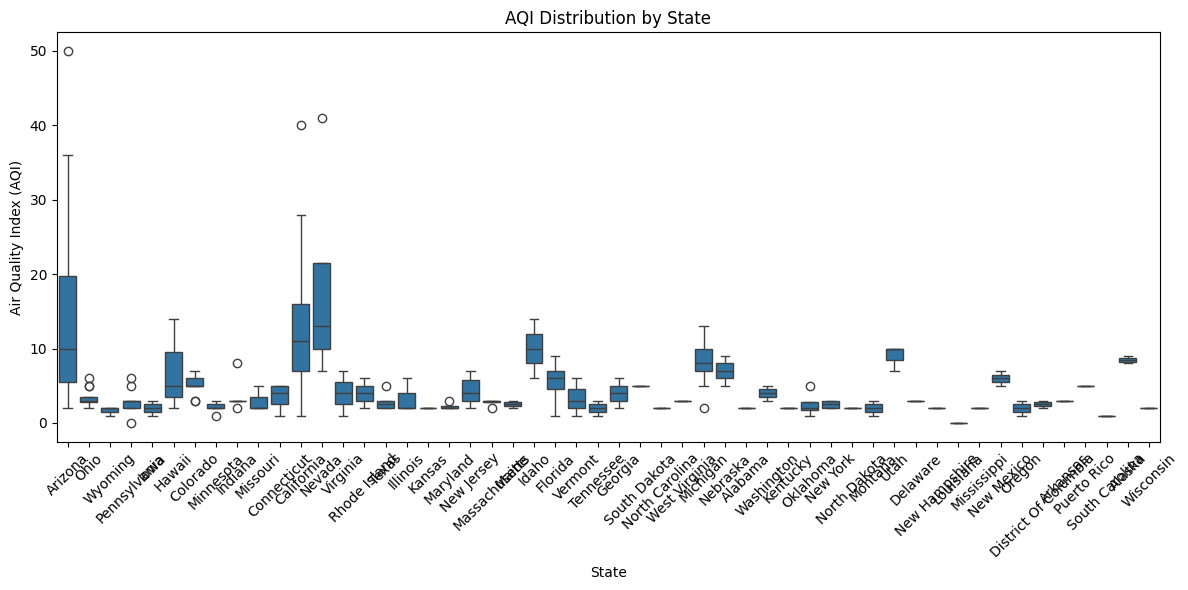

In [57]:
# Code Here
plt.figure(figsize=(12, 6))
sns.boxplot(data=aqi, x='state_name', y='aqi')
plt.xticks(rotation=45)
plt.title('AQI Distribution by State')
plt.xlabel('State')
plt.ylabel('Air Quality Index (AQI)')
plt.tight_layout()
plt.show()

**Question:** Based on the data and your visualizations, which state(s) do you suspect will be most affected by this policy?

A: Arizona, Pennsylvania, California, Indiana, Connecticut,Nevada, Virginia, West Virginia

### Construct a confidence interval for the RRE state with the highest mean AQI

Recall the 4-step process in constructing a confidence interval:

1.   Identify a sample statistic.
2.   Choose a confidence level.
3.   Find the margin of error. 
4.   Calculate the interval.

### Construct your sample statistic

To contruct your sample statistic, find the mean AQI for CA.

In [80]:
# Find the mean aqi for CA state.
# we need only California state data
california_aqi = aqi[aqi['state_name'] == 'California']['aqi']
sample_mean = np.mean(california_aqi)
sample_std = np.std(california_aqi, ddof=1)

# Standard error (SE)
n = len(california_aqi)
standard_error = sample_std / np.sqrt(n)
standard_error


np.float64(0.8987209641127412)

### Choose your confidence level

Choose your confidence level for your analysis. The most typical confidence level chosen is 95%; however, you can choose 90% or 99% if you want decrease or increase (respectively) your level of confidence about your result.

In [101]:
# Input your confidence level here:  95%

### Find your margin of error (ME)

Recall **margin of error = z * standard error**, where z is the appropriate z-value for the given confidence level. To calculate your margin of error:

- Find your z-value. 
- Find the approximate z for common confidence levels.
- Calculate your **standard error** estimate. 

| Confidence Level | Z Score |
| --- | --- |
| 90% | 1.65 |
| 95% | 1.96 |
| 99% | 2.58 |


In [99]:
# Begin by identifying the z associated with your chosen confidence level.
z_value = 1.96

# Next, calculate your standard error.
standard_error
# we already calculated the standard error while calculation mean, we are calling the variable here


# Lastly, use the preceding result to calculate your margin of error.
margin_of_error = 1.96 * standard_error
margin_of_error


np.float64(1.7614930896609726)

### Calculate your interval

Calculate both a lower and upper limit surrounding your sample mean to create your interval.

In [100]:
# Calculate your confidence interval (upper and lower limits).
lower_bound = sample_mean - margin_of_error
upper_bound = sample_mean + margin_of_error

print(f"95% Confidence Interval for California's mean AQI: ({lower_bound:.2f}, {upper_bound:.2f})")

95% Confidence Interval for California's mean AQI: (10.36, 13.88)


### Alternative: Construct the interval using `scipy.stats.norm.interval()`

`scipy` presents a simpler solution to developing a confidence interval. To use this, first import the `stats` module from `scipy`.

In [ ]:
# Import stats from scipy.
from scipy import stats

## Step 4: Results and evaluation

### Recalculate your confidence interval

Provide your chosen `confidence_level`, `sample_mean`, and `standard_error` to `stats.norm.interval()` and recalculate your confidence interval.

In [103]:
# Code Here
stats.norm.interval(0.95, loc=sample_mean, scale=standard_error) 

(np.float64(10.359751399400034), np.float64(13.882672843024208))

# Considerations

**What are some key takeaways that you learned from this project?**

A: how to build confidence intervals and understand the importance of standard error in the process

**What findings would you share with others?**

A: based on the aqi data collected by the RRE, we are 95% confident that the average air quality index for California falls between 10.35 and 13.88.

**What would you convey to external readers?**

A: this policy would be beneficial for the RRE states and actually lead to better quality of air

**References**

[seaborn.boxplot — seaborn 0.12.1 documentation](https://seaborn.pydata.org/generated/seaborn.boxplot.html). (n.d.). 